## Gradient Descent

In [19]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

In [20]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

In [21]:
#compute cost
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0
    for i in range (m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        cost_sum += cost
    total_cost = 1/(2 * m) * cost_sum
    return float(total_cost)

In [22]:
# implementing gradient descent
def compute_gradient(x, y, w, b):
    dj_dw = 0
    dj_db = 0
    m = x.shape[0]
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = (f_wb - y[i])
        dj_dw += dj_dw_i
        dj_db += dj_db_i

    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw, dj_db

In [23]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    """
    perform gradient descent to fit w, b. updates w, b by taking num_iters gradient steps with learning rate alpha.
    Args:
        x (ndarray, (m,)): data, m examples
        y (ndarray, (m,)): target values
        w_in, b_in (scalar): initial values of model parameters
        alpha (float): learning rate
        num_iters (int): no. of iterations
        cost_function: function to call produced cost
        gradient_function: function to call produced gradient
    Returns:
        w (scalar): updated value of w after running gradient descent
        b (scalar): updated value of b after running gradient descent
        J_history(List): history of cost values
        p_history(List): history of parameters [w,b]
    """

    j_history = []
    p_history = []
    b = b_in
    w = w_in
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        if i < 100000:
            j_history.append(cost_function(x, y, w, b))
            p_history.append([w,b])

        if i% math.ceil(num_iters/10) == 0:
            print(f"Iterations{i:4}: Cost {j_history[-1]: 0.2e}", f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}", f"w: {w: 0.3e}, b: {b: 0.3e}")

    return w, b, j_history, p_history

In [77]:
#initiaalize parameters
w_init = 0
b_init = 0
tmp_alpha = 1.0e-2
iterations = 10000
w_final, b_final, j_hist, p_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent : ({w_final: 8.4f}, {b_final: 8.4f})")

Iterations   0: Cost  7.93e+04 dj_dw: -6.500e+02, dj_db: -4.000e+02 w:  6.500e+00, b:  4.000e+00
Iterations1000: Cost  3.41e+00 dj_dw: -3.712e-01, dj_db:  6.007e-01 w:  1.949e+02, b:  1.082e+02
Iterations2000: Cost  7.93e-01 dj_dw: -1.789e-01, dj_db:  2.895e-01 w:  1.975e+02, b:  1.040e+02
Iterations3000: Cost  1.84e-01 dj_dw: -8.625e-02, dj_db:  1.396e-01 w:  1.988e+02, b:  1.019e+02
Iterations4000: Cost  4.28e-02 dj_dw: -4.158e-02, dj_db:  6.727e-02 w:  1.994e+02, b:  1.009e+02
Iterations5000: Cost  9.95e-03 dj_dw: -2.004e-02, dj_db:  3.243e-02 w:  1.997e+02, b:  1.004e+02
Iterations6000: Cost  2.31e-03 dj_dw: -9.660e-03, dj_db:  1.563e-02 w:  1.999e+02, b:  1.002e+02
Iterations7000: Cost  5.37e-04 dj_dw: -4.657e-03, dj_db:  7.535e-03 w:  1.999e+02, b:  1.001e+02
Iterations8000: Cost  1.25e-04 dj_dw: -2.245e-03, dj_db:  3.632e-03 w:  2.000e+02, b:  1.000e+02
Iterations9000: Cost  2.90e-05 dj_dw: -1.082e-03, dj_db:  1.751e-03 w:  2.000e+02, b:  1.000e+02
(w,b) found by gradient descen

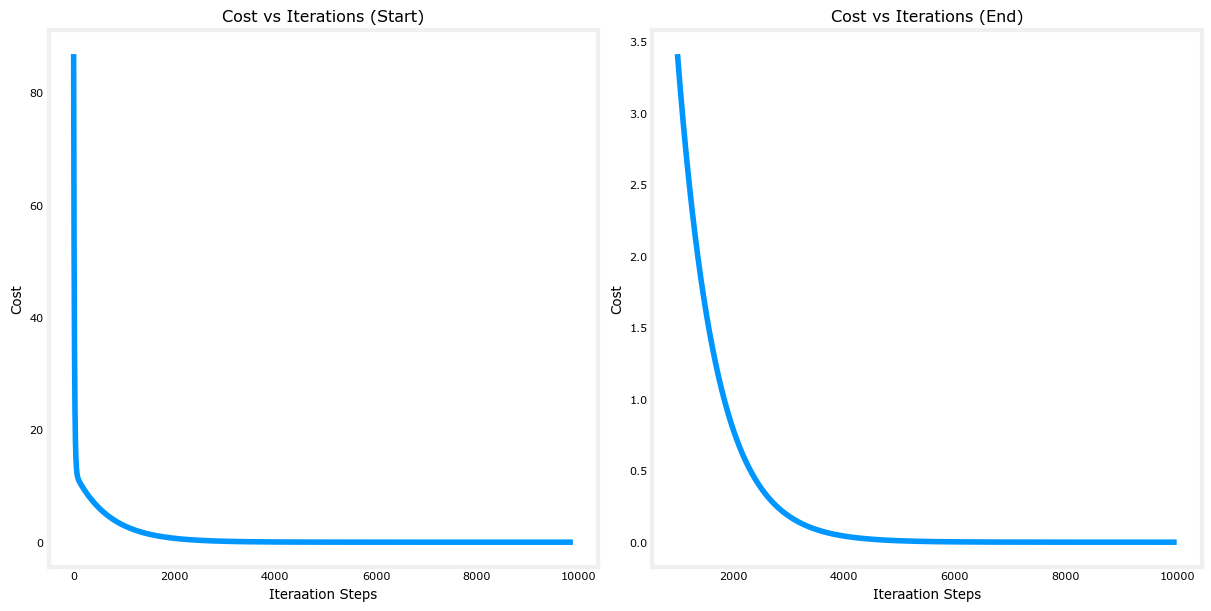

In [78]:
#plotting cost v/s iterations of gradient descent
fig, (ax1, ax2) = plt.subplots(1,2, constrained_layout = True, figsize = (12,6))
ax1.plot(j_hist[100:])
ax2.plot(1000 + np.arange(len(j_hist[1000:])), j_hist[1000:])
ax1.set_title("Cost vs Iterations (Start)")
ax2.set_title("Cost vs Iterations (End)")
ax1.set_xlabel("Iteraation Steps")
ax2.set_xlabel("Iteraation Steps")
ax1.set_ylabel("Cost")
ax2.set_ylabel("Cost")
plt.show()

In [79]:
#Predictions
print(f"1000 sqft house: ${(w_final*1.0 + b_final) * 1000: 0.1f}")
print(f"1200 sqft house: ${(w_final*1.2 + b_final) * 1000: 0.1f}")
print(f"4000 sqft house: ${(w_final*4.0 + b_final) * 1000: 0.1f}")

1000 sqft house: $ 300004.4
1200 sqft house: $ 340003.0
4000 sqft house: $ 899983.0


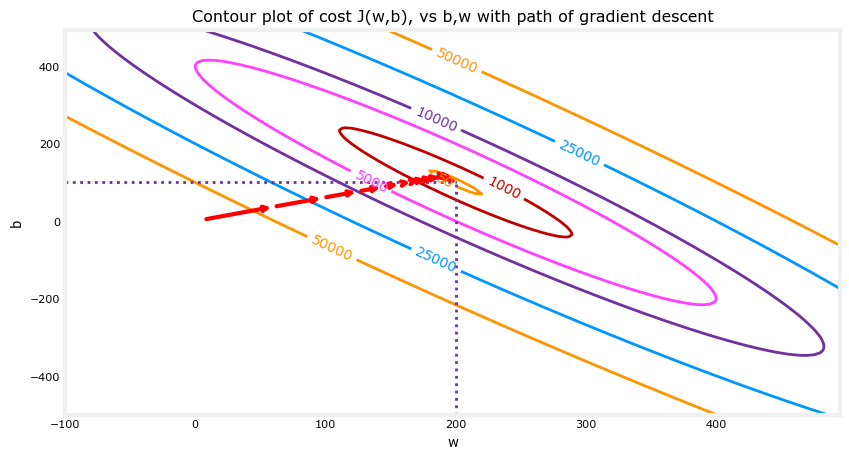

In [80]:
#plotting gradient descent
fig, ax = plt.subplots(1, 1, figsize = (10,5))
plt_contour_wgrad(x_train, y_train, p_hist, ax)

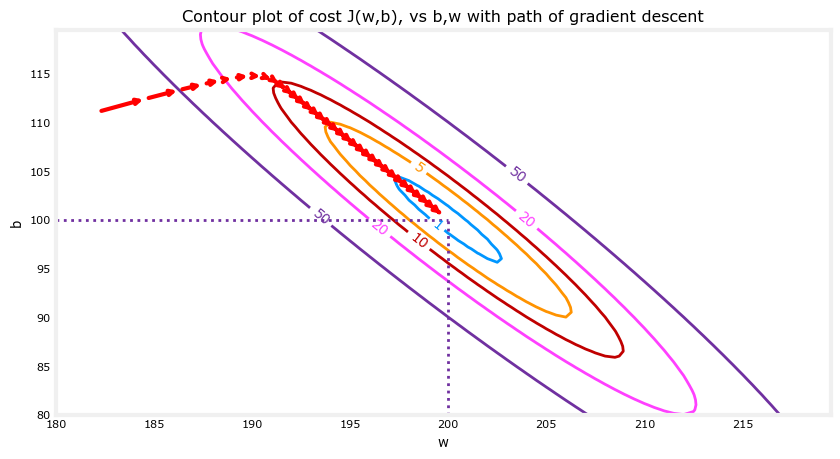

In [81]:
fig, ax = plt.subplots(1, 1, figsize = (10,5))
plt_contour_wgrad(x_train, y_train, p_hist, ax, w_range = [180, 220, 0.5], b_range = [80, 120, 0.5], contours = [1,5,10,20,50], resolution = 0.6)

Iterations   0: Cost  1.05e+05 dj_dw: -6.500e+02, dj_db: -4.000e+02 w:  4.004e+02, b:  2.464e+02
Iterations   1: Cost  1.30e+05 dj_dw:  7.206e+02, dj_db:  4.470e+02 w: -4.349e+01, b: -2.895e+01
Iterations   2: Cost  1.60e+05 dj_dw: -8.022e+02, dj_db: -4.942e+02 w:  4.506e+02, b:  2.755e+02
Iterations   3: Cost  1.97e+05 dj_dw:  8.898e+02, dj_db:  5.514e+02 w: -9.747e+01, b: -6.421e+01
Iterations   4: Cost  2.44e+05 dj_dw: -9.900e+02, dj_db: -6.104e+02 w:  5.124e+02, b:  3.118e+02
Iterations   5: Cost  3.01e+05 dj_dw:  1.099e+03, dj_db:  6.804e+02 w: -1.644e+02, b: -1.073e+02
Iterations   6: Cost  3.71e+05 dj_dw: -1.222e+03, dj_db: -7.539e+02 w:  5.883e+02, b:  3.571e+02
Iterations   7: Cost  4.58e+05 dj_dw:  1.356e+03, dj_db:  8.396e+02 w: -2.472e+02, b: -1.601e+02
Iterations   8: Cost  5.66e+05 dj_dw: -1.508e+03, dj_db: -9.309e+02 w:  6.818e+02, b:  4.134e+02
Iterations   9: Cost  6.98e+05 dj_dw:  1.675e+03, dj_db:  1.036e+03 w: -3.497e+02, b: -2.249e+02


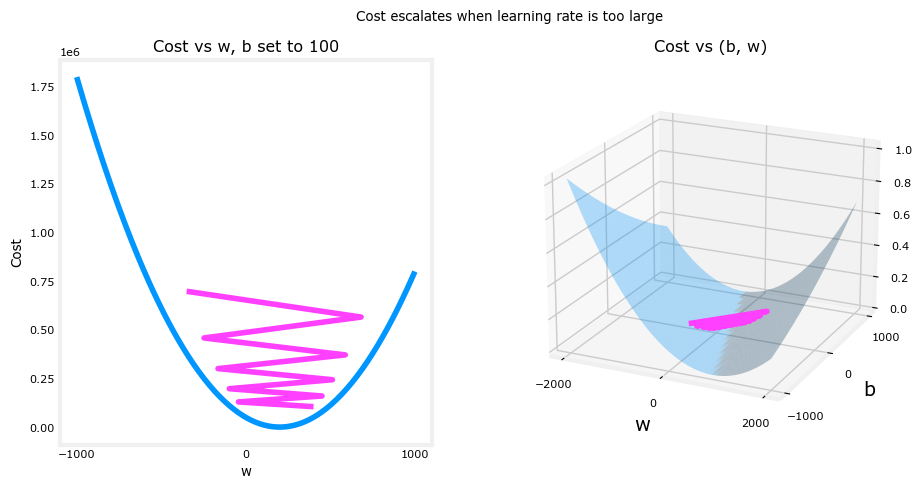

In [85]:
w_init = 0
b_init = 0
iterations = 10
tmp_alpha = 0.616
w_final, b_final, j_hist, p_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)

plt_divergence(p_hist, j_hist, x_train, y_train)
plt.show()